# Franka 离屏渲染与连杆坐标系

设置关节角后渲染单视角和多视角图片，并核对 MDH 连杆帧与 MuJoCo body 的位置、姿态。只调用 `mj_forward`，不步进物理，也不打开交互窗口。

需要可用的 OpenGL 离屏后端；无桌面环境时可在启动内核前设置 `MUJOCO_GL=egl`。坐标约定与雅可比的数值检查见 [kinematics.ipynb](kinematics.ipynb)。

In [10]:
import sys
from pathlib import Path


# 根据项目标记定位根目录，支持从仓库或 notebook 目录启动。
def _project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src" / "robot_model" / "__init__.py"
        ).is_file():
            return candidate
    raise FileNotFoundError("找不到含 pyproject.toml 和 src/robot_model 的项目根目录")


_ROOT = _project_root(Path.cwd().resolve())
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import matplotlib.pyplot as plt
import mujoco
import numpy as np

from robot_model import Robot
from robot_model.robots.franka import (
    PANDA_MDH_BODY_NAMES,
    PANDA_MDH_PARMS,
    panda_xml_path,
)

print('root  :', _ROOT)
print('mujoco:', mujoco.__version__)

root  : /home/xiaomeng/code
mujoco: 3.4.0


In [11]:
NARM = 7

xml = panda_xml_path().parent / '_viz_q0_scene.xml'
if not xml.is_file():
    xml = panda_xml_path()

model = mujoco.MjModel.from_xml_path(str(xml))
data = mujoco.MjData(model)
robot = Robot.from_mdh('franka_panda_arm', PANDA_MDH_PARMS)

q_home = np.array(model.key('home').qpos[:NARM], dtype=float)
# q = q_home.copy()  # 换姿态改这里，例如 np.zeros(NARM)
q = np.zeros(NARM)
print('xml:', xml)
print('q  :', np.array2string(q, precision=4))

xml: /home/xiaomeng/code/robot_model/assets/models/franka_panda/_viz_q0_scene.xml
q  : [0. 0. 0. 0. 0. 0. 0.]


## 渲染

`set_q` 只写 `qpos` 后做一次 `mj_forward`，即纯运动学，不步进物理。

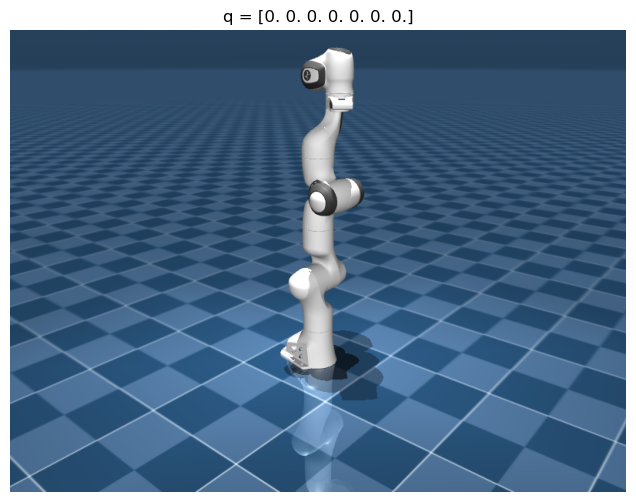

In [12]:
renderer = mujoco.Renderer(model, height=600, width=800)
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2.0
camera.azimuth = 130
camera.elevation = -20
camera.lookat[:] = [0.0, 0.0, 0.4] #注视点、轨道中心的世界坐标


def set_q(q):
    data.qpos[:] = 0.0
    data.qpos[:NARM] = np.asarray(q, dtype=float).reshape(NARM)
    mujoco.mj_forward(model, data)


def render(q, *, azimuth=None, elevation=None):
    set_q(q)
    if azimuth is not None:
        camera.azimuth = azimuth
    if elevation is not None:
        camera.elevation = elevation
    renderer.update_scene(data, camera)
    return renderer.render()


plt.figure(figsize=(8, 6))
plt.imshow(render(q))
plt.axis('off')
plt.title(f'q = {np.array2string(q, precision=2)}')
plt.show()

## 连杆位姿对照

MDH 连杆帧对应 MuJoCo 的 `link1`～`link7`。位置差和旋转矩阵差应接近浮点误差。

In [13]:
def fk_report(q):
    """逐连杆对比本库 FK 与 MuJoCo body 位姿，返回 (body, pos_err, rot_err)。"""
    set_q(q)
    rows = []
    for i, name in enumerate(PANDA_MDH_BODY_NAMES):
        T = robot.fk_numpy(q, link=i)
        bid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, name)
        R_mj = data.xmat[bid].reshape(3, 3)
        pos_err = float(np.linalg.norm(T[:3, 3] - data.xpos[bid]))
        rot_err = float(np.linalg.norm(T[:3, :3] @ R_mj.T - np.eye(3)))
        rows.append((name, pos_err, rot_err))
    return rows


print(f"{'body':<8}{'pos_err':>12}{'rot_err':>12}")
for name, pos_err, rot_err in fk_report(q):
    print(f'{name:<8}{pos_err:>12.2e}{rot_err:>12.2e}')

body         pos_err     rot_err
link1       0.00e+00    0.00e+00
link2       0.00e+00    3.85e-16
link3       0.00e+00    7.69e-16
link4       4.16e-17    7.69e-16
link5       0.00e+00    1.15e-15
link6       0.00e+00    1.35e-15
link7       6.94e-17    1.54e-15


## 多视角

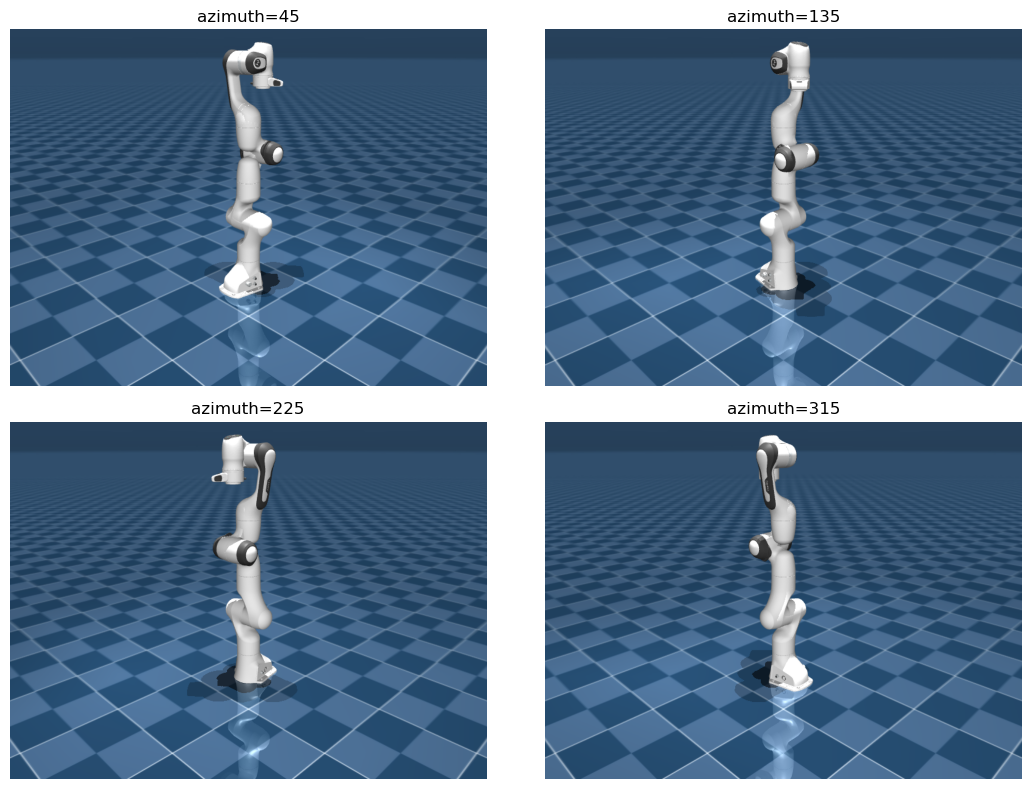

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, az in zip(axes.ravel(), [45, 135, 225, 315]):
    ax.imshow(render(q, azimuth=az))
    ax.set_title(f'azimuth={az}')
    ax.axis('off')
fig.tight_layout()
plt.show()

camera.azimuth = 130

## MDH、DH 与 PoE 的连杆帧

`to_dh()` 和 `to_poe()` 保持末端位姿。此模型的 MDH 与 PoE 中间帧也与 MJCF 的 body 帧对齐；标准 DH 中间帧位于不同的关节轴，其位置与朝向可以不同。下面分别比较中间帧和末端帧。

In [15]:
dh = robot.to_dh()
poe = robot.to_poe()


def convention_report(q):
    """三种约定逐连杆对比 MuJoCo body 位姿。"""
    set_q(q)
    models = [('MDH', robot), ('DH', dh), ('PoE', poe)]
    head = 'body'.ljust(7)
    for name, _ in models:
        head += (name + ' pos').rjust(11) + (name + ' rot').rjust(11)
    print(head)
    for i, body in enumerate(PANDA_MDH_BODY_NAMES):
        bid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body)
        p_mj, R_mj = data.xpos[bid], data.xmat[bid].reshape(3, 3)
        line = body.ljust(7)
        for _, rb in models:
            T = rb.fk_numpy(q, link=i)
            pos_err = np.linalg.norm(T[:3, 3] - p_mj)
            rot_err = np.linalg.norm(T[:3, :3] @ R_mj.T - np.eye(3))
            line += f'{pos_err:>11.1e}{rot_err:>11.1e}'
        print(line)


convention_report(q)

body       MDH pos    MDH rot     DH pos     DH rot    PoE pos    PoE rot
link1      0.0e+00    0.0e+00    0.0e+00    2.0e+00    0.0e+00    0.0e+00
link2      0.0e+00    3.8e-16    0.0e+00    2.0e+00    0.0e+00    3.8e-16
link3      0.0e+00    7.7e-16    8.3e-02    2.0e+00    0.0e+00    7.7e-16
link4      4.2e-17    7.7e-16    8.2e-02    2.0e+00    4.2e-17    7.7e-16
link5      0.0e+00    1.2e-15    0.0e+00    2.0e+00    0.0e+00    1.2e-15
link6      0.0e+00    1.3e-15    8.8e-02    2.0e+00    0.0e+00    1.3e-15
link7      6.9e-17    1.5e-15    6.9e-17    1.5e-15    6.9e-17    1.5e-15


In [16]:
# 末端帧：换约定后必须与 MDH 严格一致
for name, other in (('DH', dh), ('PoE', poe)):
    r = robot.compare_fk(other, q)
    pos_err, rot_err = r['pos_err'], r['rot_err']
    print(f'末端 MDH vs {name:<4} pos_err={pos_err:.2e}  rot_err={rot_err:.2e}')

末端 MDH vs DH   pos_err=0.00e+00  rot_err=0.00e+00
末端 MDH vs PoE  pos_err=0.00e+00  rot_err=0.00e+00


### 参数表

查看同一机器人在三种约定下的参数。转换到标准 DH 后，最后一行的 `alpha`、`a` 为零；末端变换保持一致。

In [17]:
robot.print_dh_table()  # MDH：原始参数
dh.print_dh_table()  # 标准 DH：to_dh() 转换所得
poe.print_poe_table()  # PoE：零位抽出的空间旋量

Joint,a,d,α,θ,关节类型
Joint1,0,0.333,0,q1,转动关节
Joint2,0,0,-pi/2,q2,转动关节
Joint3,0,0.316,pi/2,q3,转动关节
Joint4,0.0825,0,pi/2,q4,转动关节
Joint5,-0.0825,0.384,-pi/2,q5,转动关节
Joint6,0,0,pi/2,q6,转动关节
Joint7,0.088,0,pi/2,q7,转动关节


Joint,a,d,α,θ,关节类型
Joint1,0,0.333,-pi/2,q1,转动关节
Joint2,0,0,pi/2,q2,转动关节
Joint3,0.0825,0.316,pi/2,q3,转动关节
Joint4,-0.0825,0,-pi/2,q4,转动关节
Joint5,0,0.384,pi/2,q5,转动关节
Joint6,0.088,0,pi/2,q6,转动关节
Joint7,0,0,0,q7,转动关节


Joint,ωx,ωy,ωz,vx,vy,vz,关节类型
Joint1,0,0,1,0,0,0,转动关节
Joint2,0,1,0,-0.333,0,0,转动关节
Joint3,0,0,1,0,0,0,转动关节
Joint4,0,-1,0,0.649,0,-0.0825,转动关节
Joint5,0,0,1,0,0,0,转动关节
Joint6,0,-1,0,1.033,0,0,转动关节
Joint7,0,0,-1,0,0.088,0,转动关节
